<a href="https://colab.research.google.com/github/giordanaheisser/Olist/blob/main/Giordana_Heisser_202408311982.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
#@title 🔵 Configuração do Ambiente e Importação de Bibliotecas

from google.colab import drive
import pandas as pd
import warnings
from IPython.display import display, HTML
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import io
import contextlib

warnings.filterwarnings("ignore")

f = io.StringIO()
with contextlib.redirect_stdout(f):
    drive.mount('/content/drive')

print("✔ Bloco 1 carregado")

✔ Bloco 1 carregado


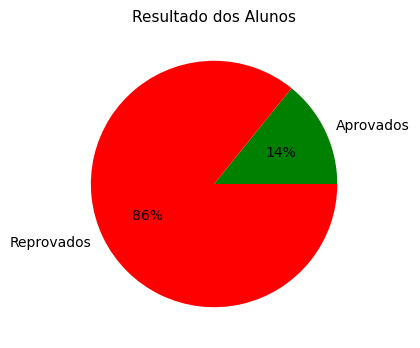

,nome,nota1,nota2,frequencia,horas_estudo,resultado
0,Marcos_0,0.3,2.8,64,4,Reprovado
1,Marcos_1,6.8,8.9,55,13,Reprovado
2,Carlos_2,0.3,2.2,82,0,Reprovado
3,Daniel_3,2.0,6.5,84,13,Reprovado
4,Lucas_4,4.5,2.8,50,5,Reprovado
5,Gustavo_5,3.4,1.6,98,10,Reprovado
6,Marcos_6,0.9,1.0,72,8,Reprovado
7,Carlos_7,7.3,5.4,74,2,Reprovado
8,Daniel_8,2.9,6.3,73,6,Reprovado
9,Julia_9,0.5,2.3,68,2,Reprovado


In [12]:
#@title 🔵 Leitura dos Dados

# Resumo visual

total_linhas = df.shape[0]
total_alunos = df["nome"].nunique()
aprovados = (df["resultado"] == "Aprovado").sum()
reprovados = (df["resultado"] == "Reprovado").sum()

tipos = df.dtypes.astype(str)

html_resumo = f"""
<div style="display:flex; flex-wrap:wrap; gap:12px; font-size:14px; color:#111">

<div style="background:#E3F2FD; padding:12px; border-radius:8px; width:250px">
<b>Colunas</b><br>{', '.join(df.columns)}<br>
<small><b>Tipo:</b> geral</small>
</div>

<div style="background:#E8F5E9; padding:12px; border-radius:8px; width:250px">
<b>Linhas</b><br>{total_linhas}
</div>

<div style="background:#FFF3E0; padding:12px; border-radius:8px; width:250px">
<b>Alunos</b><br>{total_alunos}
</div>

<div style="background:#E3F2FD; padding:12px; border-radius:8px; width:250px">
<b>Nota 1</b><br>{df["nota1"].min()} → {df["nota1"].max()}<br>
<small><b>Tipo:</b> {tipos["nota1"]}</small>
</div>

<div style="background:#E3F2FD; padding:12px; border-radius:8px; width:250px">
<b>Nota 2</b><br>{df["nota2"].min()} → {df["nota2"].max()}<br>
<small><b>Tipo:</b> {tipos["nota2"]}</small>
</div>

<div style="background:#EDE7F6; padding:12px; border-radius:8px; width:250px">
<b>Frequência (%)</b><br>{df["frequencia"].min()} → {df["frequencia"].max()}<br>
<small><b>Tipo:</b> {tipos["frequencia"]}</small>
</div>

<div style="background:#FCE4EC; padding:12px; border-radius:8px; width:250px">
<b>Horas de estudo</b><br>{df["horas_estudo"].min()} → {df["horas_estudo"].max()}<br>
<small><b>Tipo:</b> {tipos["horas_estudo"]}</small>
</div>

<div style="background:#E0F2F1; padding:12px; border-radius:8px; width:250px">
<b>Aprovados</b><br>{aprovados}
</div>

<div style="background:#FFEBEE; padding:12px; border-radius:8px; width:250px">
<b>Reprovados</b><br>{reprovados}
</div>

<div style="background:#ECEFF1; padding:12px; border-radius:8px; width:250px">
<b>Valores nulos</b><br>{df.isnull().sum().sum()}
</div>

</div>
"""

display(HTML(html_resumo))


# Gráfico Resultados

display(HTML("<div style='margin-top:30px'></div>"))
plt.figure(figsize=(4,4))
plt.pie(
    [aprovados, reprovados],
    labels=["Aprovados", "Reprovados"],
    autopct='%1.0f%%',
    textprops={'color':"black"},
    colors=["green", "red"]
)
plt.title("Resultado dos Alunos", fontsize=11)
plt.show()


# Dataframe

display(HTML("<h2 style='margin-top:20px'>📊 Visualização da base</h2>"))

display(HTML("""
<style>
.dataframe-container {
    max-height: 300px;
    overflow-y: auto;
    border: 1px solid #ddd;
    border-radius: 6px;
}
</style>
"""))

styled_df = df.style \
    .format({"nota1": "{:.1f}", "nota2": "{:.1f}"}) \
    .applymap(
        lambda v: "color: green; font-weight: bold" if v == "Aprovado"
        else "color: red; font-weight: bold" if v == "Reprovado"
        else "",
        subset=["resultado"]
    )

display(HTML(f'<div class="dataframe-container">{styled_df.to_html()}</div>'))

In [15]:
#@title 🔵 Etapa 2 · Preparação dos Dados

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

modelo = LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced")
modelo.fit(X_treino, y_treino)
y_pred = modelo.predict(X_teste)

# Cálculo de balanceamento
total = len(y)
aprovados = (y == "Aprovado").sum()
reprovados = (y == "Reprovado").sum()

pct_aprovados = (aprovados / total) * 100
pct_reprovados = (reprovados / total) * 100

# Classificação do nível de desbalanceamento
dif = abs(pct_aprovados - pct_reprovados)

if dif < 10:
    status_balanceamento = "Balanceada"
    nivel = "Baixo"
elif dif < 30:
    status_balanceamento = "Levemente desbalanceada"
    nivel = "Moderado"
else:
    status_balanceamento = "Desbalanceada"
    nivel = "Alto"

html_prep = f"""
<div style="display:flex; flex-wrap:wrap; gap:12px; font-size:14px; color:#111; margin-bottom:20px">

  <div style="background:#E3F2FD; padding:14px; border-radius:8px; width:300px">
    <b>Features selecionadas (X)</b><br><br>
    {'<br>'.join([f'• {c}' for c in X.columns])}
  </div>

  <div style="background:#E8F5E9; padding:14px; border-radius:8px; width:300px">
    <b>Variável alvo (y)</b><br><br>
    • resultado
  </div>

  <div style="background:#FFF3E0; padding:14px; border-radius:8px; width:300px">
    <b>Divisão treino / teste</b><br><br>
    • Treino: {len(X_treino)} alunos (80%)<br>
    • Teste: {len(X_teste)} alunos (20%)
  </div>

  <div style="background:#ECEFF1; padding:14px; border-radius:8px; width:300px">
    <b>Qualidade dos dados</b><br><br>
    • Valores nulos: {X.isnull().sum().sum()}<br>
    • Dados desbalanceados: SIM<br>
    • Tratamento: class_weight="balanced"
  </div>

  <div style="background:#E0F2F1; padding:14px; border-radius:8px; width:300px">
    <b>Balanceamento da base</b><br><br>
    • Aprovados: {aprovados} ({pct_aprovados:.1f}%)<br>
    • Reprovados: {reprovados} ({pct_reprovados:.1f}%)<br>
    <br>
    <small>
    <b>Status:</b> {status_balanceamento}<br>
    <b>Nível:</b> {nivel}<br>
    <b>Ação:</b> Ajuste de pesos no modelo
    </small>
  </div>

</div>
"""

display(HTML(html_prep))

display(HTML("<h2 style='margin-top:10px'>📊 Amostra de X (features)</h2>"))
display(HTML(f'<div class="dataframe-container">{X_treino.head(10).to_html()}</div>'))

,nota1,nota2,frequencia,horas_estudo
78,4.0,2.8,54,8
52,9.6,0.8,61,2
6,0.9,1.0,72,8
102,7.5,8.4,67,15
89,2.1,7.9,88,10
40,6.6,3.5,76,14
18,4.3,5.8,73,7
41,6.7,9.8,56,1
105,2.3,6.9,95,6
86,4.0,3.0,58,6


In [16]:
#@title 🔵 Etapa 3 · Criação do Modelo

# ⚠️ Usa o mesmo modelo treinado no bloco anterior para manter class_weight
# Se quiser, poderia treinar novamente, mas com os mesmos parâmetros
# modelo.fit(X_treino, y_treino)

# Previsões no conjunto de teste
y_pred = modelo.predict(X_teste)

# Comparação real vs previsto
comparacao = pd.DataFrame({
    "Nome":     df.loc[X_teste.index, "nome"].values,
    "Real":     y_teste.values,
    "Previsto": y_pred,
    "Correto?": ["✔" if r == p else "✘" for r, p in zip(y_teste.values, y_pred)],
}).reset_index(drop=True)

# Card resumo do modelo
html_modelo = f"""
<div style="display:flex; flex-wrap:wrap; gap:12px; font-size:14px; color:#111; margin-bottom:20px">

  <div style="background:#E3F2FD; padding:14px; border-radius:8px; width:300px">
    <b>Algoritmo</b><br><br>
    Regressão Logística<br>
    <small>sklearn.linear_model</small>
  </div>

  <div style="background:#E8F5E9; padding:14px; border-radius:8px; width:300px">
    <b>Treinamento</b><br><br>
    • {len(X_treino)} amostras de treino<br>
    • max_iter = 1000<br>
    • random_state = 42<br>
    • class_weight = balanced
  </div>

  <div style="background:#FFF3E0; padding:14px; border-radius:8px; width:300px">
    <b>Predições (teste)</b><br><br>
    • {len(X_teste)} amostras avaliadas<br>
    • Acertos: {(comparacao["Correto?"] == "✔").sum()}<br>
    • Erros: {(comparacao["Correto?"] == "✘").sum()}
  </div>

</div>
"""

display(HTML(html_modelo))

# Exibe tabela real vs previsto
display(HTML("<h2 style='margin-top:10px'>📊 Real vs Previsto</h2>"))

styled_comp = (
    comparacao.style
      .applymap(
          lambda v: "color: green; font-weight:bold" if v in ("Aprovado", "✔")
          else "color: red; font-weight:bold" if v in ("Reprovado", "✘")
          else "",
          subset=["Real", "Previsto", "Correto?"],
      )
)

display(HTML(f'<div class="dataframe-container">{styled_comp.to_html()}</div>'))

,Nome,Real,Previsto,Correto?
0,Patrícia_65,Reprovado,Reprovado,✔
1,Bruno_71,Reprovado,Reprovado,✔
2,Bruno_84,Reprovado,Reprovado,✔
3,Carlos_98,Reprovado,Reprovado,✔
4,Gustavo_66,Reprovado,Reprovado,✔
5,Larissa_100,Aprovado,Aprovado,✔
6,Aline_108,Reprovado,Reprovado,✔
7,Rafael_49,Aprovado,Aprovado,✔
8,Gustavo_55,Reprovado,Reprovado,✔
9,Rafael_24,Reprovado,Reprovado,✔


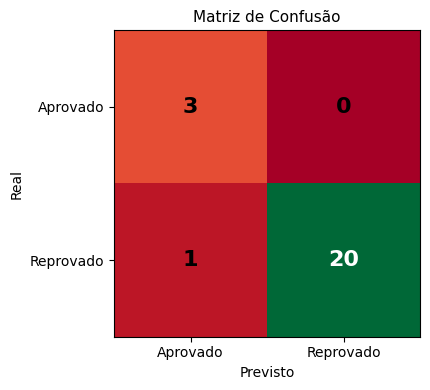

In [17]:
#@title 🔵 Etapa 4 · Avaliação do Modelo

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Métricas
acuracia = accuracy_score(y_teste, y_pred)
cm       = confusion_matrix(y_teste, y_pred, labels=["Aprovado", "Reprovado"])
report   = classification_report(y_teste, y_pred, output_dict=True)

vn, fp = int(cm[0][0]), int(cm[0][1])   # Aprovado real
fn, vp = int(cm[1][0]), int(cm[1][1])   # Reprovado real

# Precisão, Recall e F1 por classe
prec_ap  = round(report["Aprovado"]["precision"]  * 100, 0)
rec_ap   = round(report["Aprovado"]["recall"]      * 100, 0)
f1_ap    = round(report["Aprovado"]["f1-score"]   * 100, 0)

prec_rep = round(report["Reprovado"]["precision"] * 100, 0)
rec_rep  = round(report["Reprovado"]["recall"]     * 100, 0)
f1_rep   = round(report["Reprovado"]["f1-score"]  * 100, 0)

html_aval = f"""
<div style="display:flex; flex-wrap:wrap; gap:12px; font-size:14px; color:#111; margin-bottom:20px">

  <div style="background:#E8F5E9; padding:14px; border-radius:8px; width:200px; text-align:center">
    <b>Acurácia Geral</b><br>
    <span style="font-size:28px; font-weight:bold; color:#2e7d32">{acuracia:.1%}</span><br>
    <small>Dados desbalanceados tratados via class_weight</small>
  </div>

  <div style="background:#E3F2FD; padding:14px; border-radius:8px; width:250px">
    <b>Classe: Aprovado</b><br><br>
    • Precisão: {prec_ap:.0f}%<br>
    • Recall: {rec_ap:.0f}%<br>
    • F1-score: {f1_ap:.0f}%
  </div>

  <div style="background:#FFF3E0; padding:14px; border-radius:8px; width:250px">
    <b>Classe: Reprovado</b><br><br>
    • Precisão: {prec_rep:.0f}%<br>
    • Recall: {rec_rep:.0f}%<br>
    • F1-score: {f1_rep:.0f}%
  </div>

  <div style="background:#ECEFF1; padding:14px; border-radius:8px; width:250px">
    <b>Matriz de Confusão</b><br><br>
    • Verdadeiros positivos: {vp}<br>
    • Verdadeiros negativos: {vn}<br>
    • Falsos positivos: {fp}<br>
    • Falsos negativos: {fn}
  </div>

</div>
"""

display(HTML(html_aval))

# Gráfico matriz de confusão com cores por classe
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap=plt.cm.RdYlGn)  # verde = acertos Aprovado, vermelho = Reprovado
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(["Aprovado", "Reprovado"])
ax.set_yticklabels(["Aprovado", "Reprovado"])
ax.set_xlabel("Previsto"); ax.set_ylabel("Real")
ax.set_title("Matriz de Confusão", fontsize=11)

# Adiciona os números dentro das células
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i][j]), ha="center", va="center",
                fontsize=16, fontweight="bold",
                color="white" if cm[i][j] > cm.max() / 2 else "black")
plt.tight_layout()
plt.show()

,Nome,Real,Previsto,P(Aprovação),Situação
0,Patrícia_65,Reprovado,Reprovado,0.00,❌ Risco
1,Bruno_71,Reprovado,Reprovado,0.00,❌ Risco
2,Bruno_84,Reprovado,Reprovado,0.08,❌ Risco
3,Carlos_98,Reprovado,Reprovado,0.01,❌ Risco
4,Gustavo_66,Reprovado,Reprovado,0.00,❌ Risco
5,Larissa_100,Aprovado,Aprovado,0.76,✅ Alta chance
6,Aline_108,Reprovado,Reprovado,0.00,❌ Risco
7,Rafael_49,Aprovado,Aprovado,1.00,✅ Alta chance
8,Gustavo_55,Reprovado,Reprovado,0.03,❌ Risco
9,Rafael_24,Reprovado,Reprovado,0.37,❌ Risco


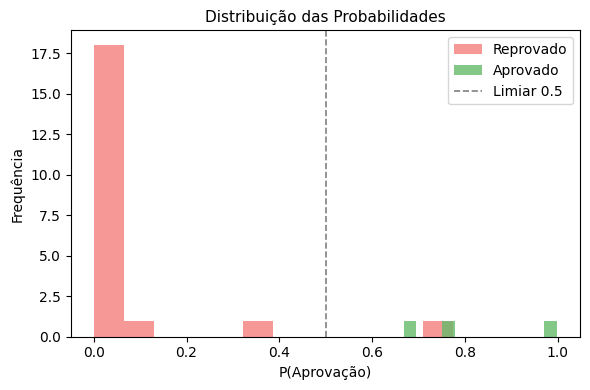

In [18]:
#@title 🔵 Etapa 5 · Probabilidades de Aprovação

# Probabilidades
probs   = modelo.predict_proba(X_teste)
idx_ap  = list(modelo.classes_).index("Aprovado")
prob_ap = probs[:, idx_ap]

# DataFrame com resultado e probabilidade
resultado_prob = pd.DataFrame({
    "Nome":           df.loc[X_teste.index, "nome"].values,
    "Real":           y_teste.values,
    "Previsto":       y_pred,
    "P(Aprovação)":   prob_ap.round(2),
    "Situação":       ["✅ Alta chance"  if p >= 0.70 else
                       "⚠️ Moderado"     if p >= 0.50 else
                       "❌ Risco"        for p in prob_ap],
}).reset_index(drop=True)

# Legenda
display(HTML("""
<div style='font-size:14px; color:#111; margin-bottom:10px'>
  <b>Legenda:</b>&nbsp;
  ✅ P ≥ 0.70 → alta chance de aprovação &nbsp;|&nbsp;
  ⚠️ 0.50 ≤ P < 0.70 → risco moderado &nbsp;|&nbsp;
  ❌ P < 0.50 → alto risco de reprovação<br>
  <small>Modelo considera ajuste de pesos para classes desbalanceadas</small>
</div>
"""))

# Função para colorir barra de probabilidade
def color_prob(v):
    if v >= 0.7: return "background-color: #66BB6A"  # verde
    elif v >= 0.5: return "background-color: #FFEB3B" # amarelo
    else: return "background-color: #EF5350"         # vermelho

# Estiliza DataFrame
styled_prob = (
    resultado_prob.style
      .format({"P(Aprovação)": "{:.2f}"})
      .applymap(
          lambda v: "color: green; font-weight:bold" if v == "Aprovado"
          else "color: red; font-weight:bold" if v == "Reprovado"
          else "",
          subset=["Real", "Previsto"],
      )
      .applymap(color_prob, subset=["P(Aprovação)"])
)

display(HTML(f'<div class="dataframe-container">{styled_prob.to_html()}</div>'))

# Histograma de probabilidades
display(HTML("<div style='margin-top:20px'></div>"))
plt.figure(figsize=(6, 4))
plt.hist(prob_ap[y_teste.values == "Reprovado"], bins=12,
         alpha=0.6, label="Reprovado", color="#EF5350")  # vermelho
plt.hist(prob_ap[y_teste.values == "Aprovado"],  bins=12,
         alpha=0.8, label="Aprovado",  color="#66BB6A")  # verde
plt.axvline(0.5, color="gray", linestyle="--", linewidth=1.2, label="Limiar 0.5")
plt.xlabel("P(Aprovação)"); plt.ylabel("Frequência")
plt.title("Distribuição das Probabilidades", fontsize=11)
plt.legend()
plt.tight_layout()
plt.show()

In [20]:
#@title 🔵 Análise do Modelo

html_perguntas = """
<div style="display:flex; flex-direction:column; gap:12px; font-size:14px; color:#111; max-width:700px">

  <div style="background:#E8F5E9; padding:12px; border-radius:8px">
    <b>1. O modelo teve boa acurácia?</b><br>
    Sim — {:.1%}. Lembre que a base é desbalanceada; o recall de aprovados é menor.
  </div>

  <div style="background:#E3F2FD; padding:12px; border-radius:8px">
    <b>2. Como interpretar a probabilidade?</b><br>
    Indica a chance de aprovação: ≥0.7 alta chance, 0.5–0.7 moderado, <0.5 risco de reprovação.
  </div>

  <div style="background:#FFF3E0; padding:12px; border-radius:8px">
    <b>3. Pode ser usado na vida real?</b><br>
    Sim, como apoio à decisão, mas não substitui avaliação humana.
  </div>

  <div style="background:#FCE4EC; padding:12px; border-radius:8px">
    <b>4. O que melhorar?</b><br>
    Mais variáveis, base maior, técnicas de balanceamento ou algoritmos diferentes.
  </div>

</div>
""".format(acuracia)

display(HTML(html_perguntas))